<a href="https://colab.research.google.com/github/asit18/ai-ml/blob/main/california_housing_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
<class 'pandas.core.frame.DataFrame'>
Index: 16164 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16164 non-null  float64
 1   latitude            16164 non-null  float64
 2   housing_m

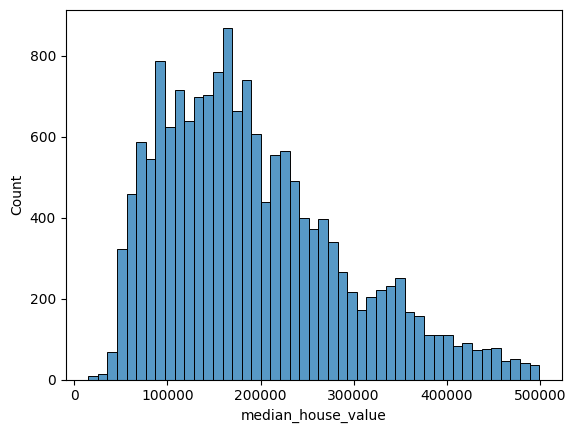

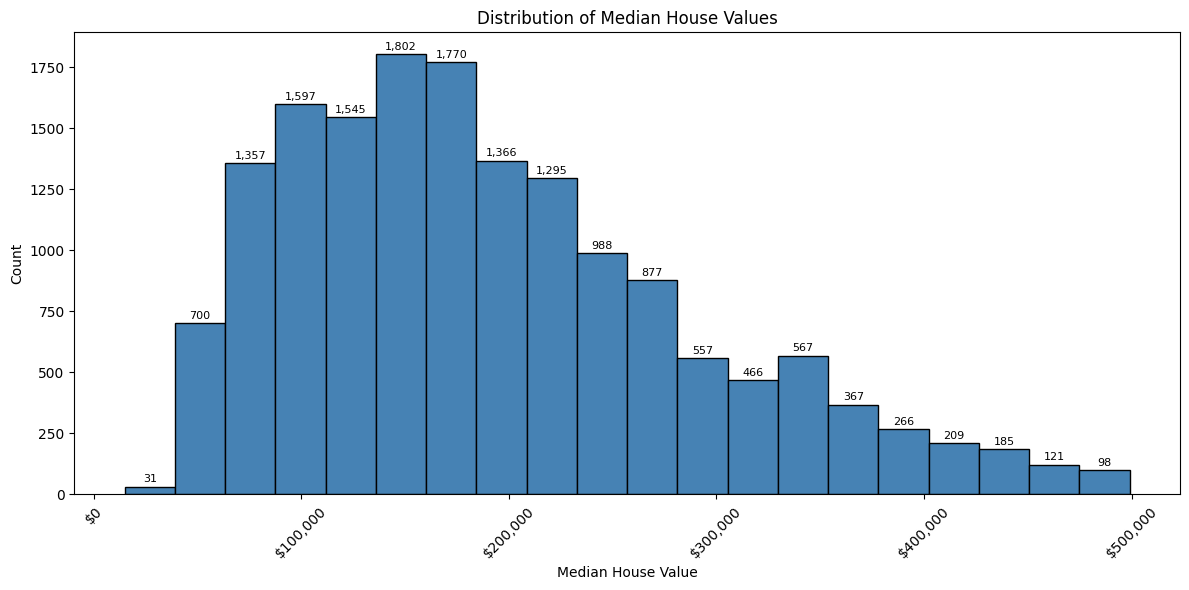

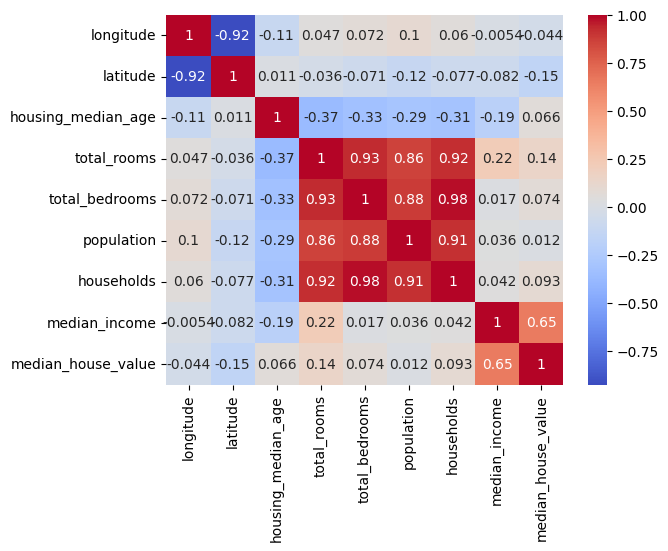

499100.0
(16164, 9)


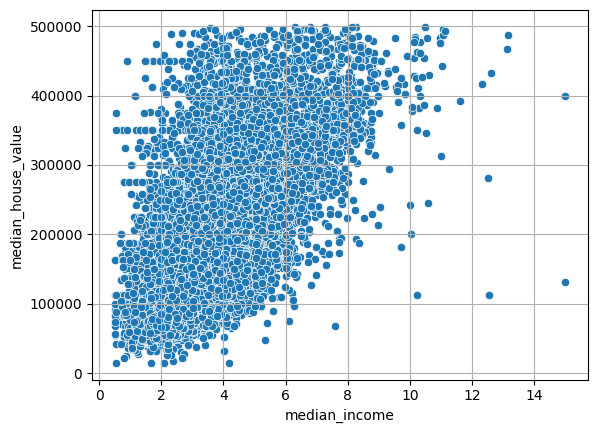

--- Degree 1 ---
MSE: 5474348461.303514
R2: 0.422960994256695
RMSE: 73988.84011324623
mean house value: 192162.50284583023
Coefficients: [40166.65517611]
Intercept: 44148.672242398374
Shape of transformed X: (16164, 1)


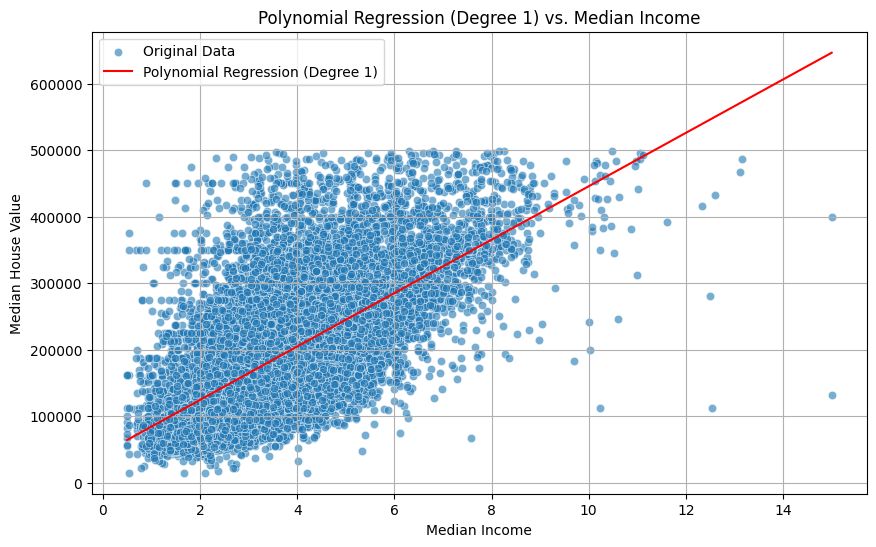

--- Degree 2 ---
MSE: 5468442999.577114
R2: 0.4235834759615308
RMSE: 73948.92155790451
mean house value: 192162.50284583023
Coefficients: [45521.70740462  -607.08745157]
Intercept: 34168.98595974341
Shape of transformed X: (16164, 2)


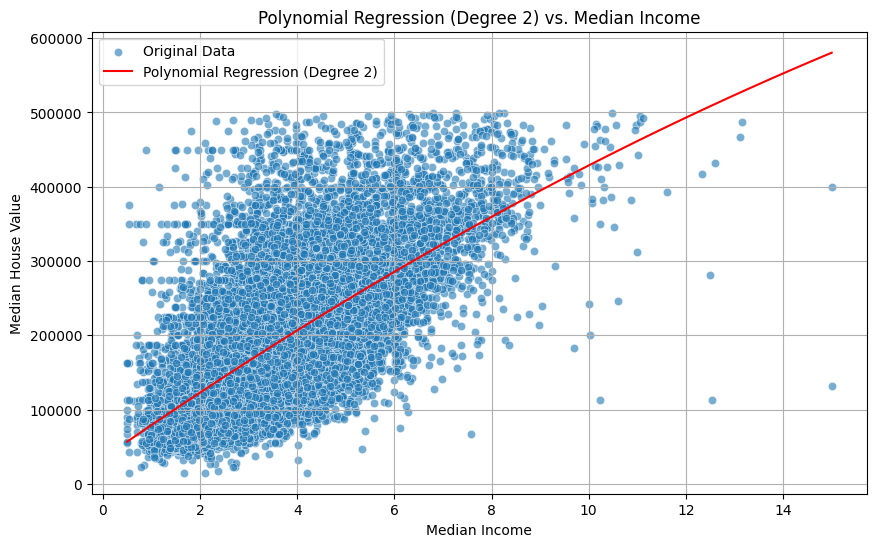

--- Degree 3 ---
MSE: 5431907844.16586
R2: 0.42743456616928976
RMSE: 73701.47789675496
mean house value: 192162.50284583023
Coefficients: [16308.59570871  5737.93940222  -394.5567093 ]
Intercept: 71893.47249770604
Shape of transformed X: (16164, 3)


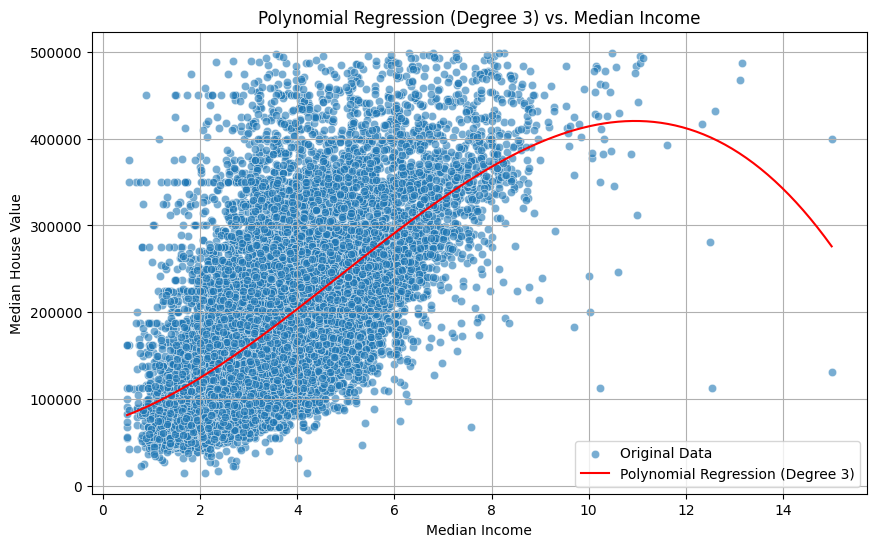

--- Degree 4 ---
MSE: 5431685210.8297
R2: 0.4274580334585665
RMSE: 73699.96750901388
mean house value: 192162.50284583023
Coefficients: [ 2.11243220e+04  4.17896922e+03 -2.02317807e+02 -7.69258561e+00]
Intercept: 67193.19555522311
Shape of transformed X: (16164, 4)


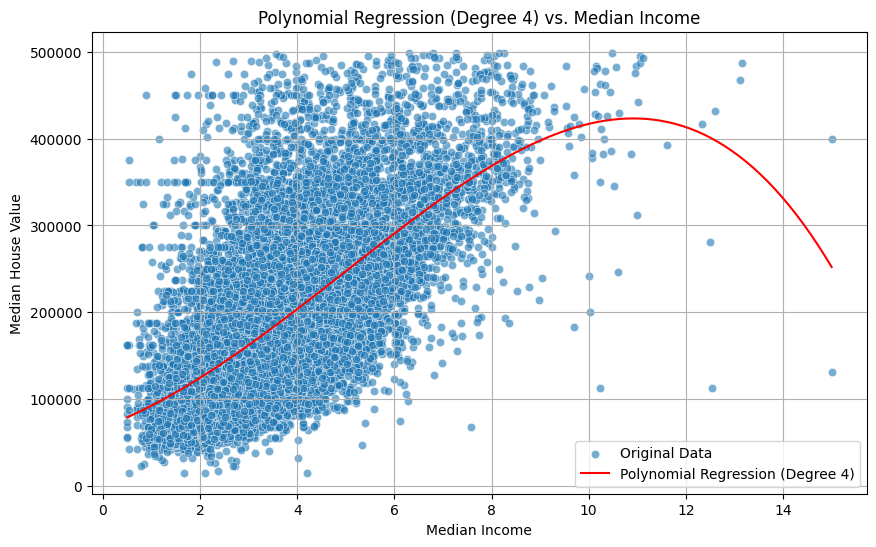

--- Degree 5 ---
MSE: 5431429779.470817
R2: 0.4274849579151312
RMSE: 73698.23457499384
mean house value: 192162.50284583023
Coefficients: [ 1.10838160e+04  8.64889230e+03 -1.06402237e+03  6.53159452e+01
 -2.19875409e+00]
Intercept: 74858.80823622427
Shape of transformed X: (16164, 5)


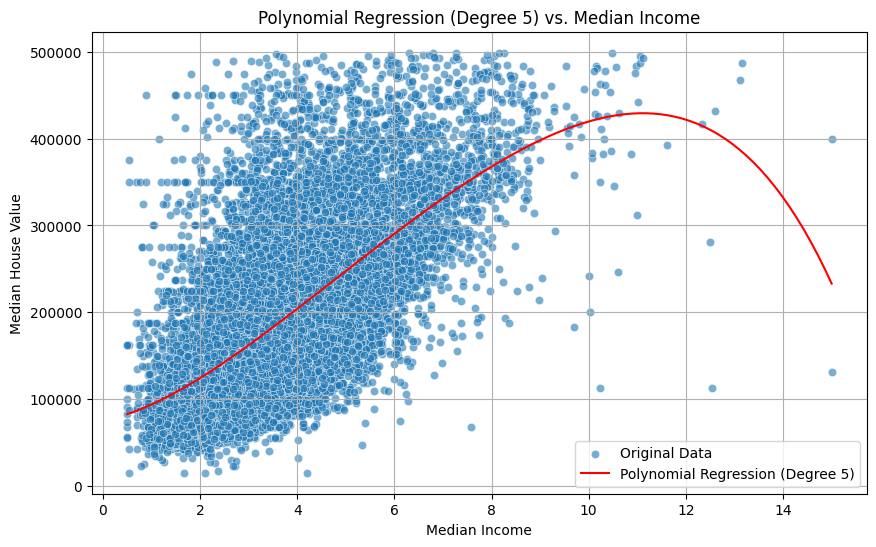

In [4]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import math # Added math import
import matplotlib.pyplot as plt
import seaborn as sns

def get_data_frame(file_path: str) -> pd.DataFrame:
    """Generates a sample data frame for a simple regression problem."""
    df = pd.read_csv(file_path)
    df.head()
    df.describe()
    df.info()
    df.shape
    df.columns
    return df
def clean_data(df:pd.DataFrame):

  df.dropna(inplace=True)
  df.drop_duplicates(inplace=True)
  df = df.query("median_house_value < 500000")
  df.describe()
  df.info()
  return df
def heatmap(df: pd.DataFrame):
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.show()
def scatter_plot(df: pd.DataFrame):
    sns.scatterplot(data=df, x="median_income", y="median_house_value")
    plt.grid(True)
    plt.show()
def build_pipeline(degree: int):
  poly_features = PolynomialFeatures(degree=degree, include_bias=False)
  lin_reg = LinearRegression()
  pipeline = Pipeline([
      ("poly_features", poly_features),
      ("lin_reg", lin_reg)
  ])
  return pipeline

def train_model(pipeline, X, y):
  return pipeline.fit(X, y)

def histogram_prices(df: pd.DataFrame):
    sns.histplot(df["median_house_value"])
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the histogram with fewer bins
    counts, edges, patches = ax.hist(
        df['median_house_value'],
        bins=20,                    # ← fewer bins = wider bars
        edgecolor='black',          # ← black border so bars are distinct
        color='steelblue'
    )

    # Add count labels on top of each bar
    for count, edge, patch in zip(counts, edges, patches):
        if count > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,  # center of bar
                patch.get_height() + 10,                  # just above bar
                f'{int(count):,}',                        # formatted number
                ha='center', va='bottom', fontsize=8
            )

    # Format x axis as dollar amounts
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )

    ax.set_xlabel('Median House Value')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Median House Values')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
def ploy_reg(df: pd.DataFrame):
  for degree in range(1, 6):
    pipeline = build_pipeline(degree)
    X = df[["median_income"]]
    y = df["median_house_value"]

    model = train_model(pipeline, X, y)
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    print(f"--- Degree {degree} ---")
    print("MSE:", mse)
    print("R2:", r2)
    rmse = math.sqrt(mse)
    print("RMSE:", rmse)
    print("mean house value:", df["median_house_value"].mean())

    # Get the LinearRegression model from the pipeline and print coefficients
    lin_reg_model = model.named_steps['lin_reg']
    print("Coefficients:", lin_reg_model.coef_)
    print("Intercept:", lin_reg_model.intercept_)
    # Also, inspect the features generated by PolynomialFeatures
    poly_features_transformer = model.named_steps['poly_features']
    X_transformed = poly_features_transformer.transform(X)
    print("Shape of transformed X:", X_transformed.shape)

    # Plotting for current degree
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X["median_income"].values.flatten(), y=y.values.flatten(), label="Original Data", alpha=0.6)

    # Create a range of x values for plotting the regression line
    X_range = pd.DataFrame(np.linspace(X["median_income"].min(), X["median_income"].max(), 100).reshape(-1, 1), columns=["median_income"])
    y_pred_range = model.predict(X_range)

    plt.plot(X_range["median_income"], y_pred_range, color='red', label=f'Polynomial Regression (Degree {degree})')
    plt.title(f'Polynomial Regression (Degree {degree}) vs. Median Income')
    plt.xlabel('Median Income')
    plt.ylabel('Median House Value')
    plt.legend()
    plt.grid(True)
    plt.show()

def main():
  df = get_data_frame("sample_data/california_housing_train.csv")
  df = clean_data(df)
  histogram_prices(df)
  heatmap(df)
  print(df['median_house_value'].max())
  print(df.shape)
  scatter_plot(df)
  ploy_reg(df)



if __name__ == '__main__':
    main()